In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("Travel details dataset.csv")

df.columns = df.columns.str.strip()

print("=================================")
print("FIRST FIVE ROWS")
print("=================================")

display(df.head())

FIRST FIVE ROWS


,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200


In [2]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Dataset Shape:
(139, 13)

Column Names:
Index(['Trip ID', 'Destination', 'Start date', 'End date', 'Duration (days)',
       'Traveler name', 'Traveler age', 'Traveler gender',
       'Traveler nationality', 'Accommodation type', 'Accommodation cost',
       'Transportation type', 'Transportation cost'],
      dtype='str')

Data Types:
Trip ID                   int64
Destination                 str
Start date                  str
End date                    str
Duration (days)         float64
Traveler name               str
Traveler age            float64
Traveler gender             str
Traveler nationality        str
Accommodation type          str
Accommodation cost          str
Transportation type         str
Transportation cost         str
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Trip ID 

In [3]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert dates
df["Start date"] = pd.to_datetime(
    df["Start date"],
    errors="coerce"
)

df["End date"] = pd.to_datetime(
    df["End date"],
    errors="coerce"
)

# Convert cost columns into numeric values
df["Accommodation cost"] = pd.to_numeric(
    df["Accommodation cost"],
    errors="coerce"
)

df["Transportation cost"] = pd.to_numeric(
    df["Transportation cost"],
    errors="coerce"
)

# Fill missing numerical values using mean
numeric_cols = [
    "Duration (days)",
    "Traveler age",
    "Accommodation cost",
    "Transportation cost"
]

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].mean()
)

# Fill missing categorical values
categorical_cols = [
    "Destination",
    "Traveler gender",
    "Traveler nationality",
    "Accommodation type",
    "Transportation type"
]

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
Trip ID                 0
Destination             0
Start date              2
End date                2
Duration (days)         0
Traveler name           2
Traveler age            0
Traveler gender         0
Traveler nationality    0
Accommodation type      0
Accommodation cost      0
Transportation type     0
Transportation cost     0
dtype: int64


In [4]:
print("\nDescriptive Statistics")

display(
    df[
        [
            "Duration (days)",
            "Traveler age",
            "Accommodation cost",
            "Transportation cost"
        ]
    ].describe()
)


Descriptive Statistics


,Duration (days),Traveler age,Accommodation cost,Transportation cost
count,139.000000,139.000000,139.000000,139.000000
mean,7.605839,33.175182,1672.222222,840.140845
std,1.589630,7.093473,1221.499567,494.924226
min,5.000000,20.000000,100.000000,50.000000
25%,7.000000,28.000000,1050.000000,700.000000
50%,7.000000,31.000000,1672.222222,840.140845
75%,8.000000,37.500000,1672.222222,840.140845
max,14.000000,60.000000,8000.000000,3000.000000


In [5]:
df["Total Trip Cost"] = (
    df["Accommodation cost"] +
    df["Transportation cost"]
)

print("\nTotal Trip Cost Created")

display(
    df[
        [
            "Trip ID",
            "Destination",
            "Accommodation cost",
            "Transportation cost",
            "Total Trip Cost"
        ]
    ].head()
)


Total Trip Cost Created


,Trip ID,Destination,Accommodation cost,Transportation cost,Total Trip Cost
0,1,"London, UK",1200.0,600.0,1800.0
1,2,"Phuket, Thailand",800.0,500.0,1300.0
2,3,"Bali, Indonesia",1000.0,700.0,1700.0
3,4,"New York, USA",2000.0,1000.0,3000.0
4,5,"Tokyo, Japan",700.0,200.0,900.0


In [6]:
print("\nAverage Trip Cost by Destination")

destination_avg = (
    df.groupby("Destination")["Total Trip Cost"]
    .mean()
    .sort_values(ascending=False)
)

print(destination_avg.head(10))


Average Trip Cost by Destination
Destination
Auckland, New Zealand          9500.000000
New York City, USA             6250.000000
Cape Town, South Africa        5000.000000
Vancouver, Canada              4275.000000
Honolulu, Hawaii               4200.000000
Sydney, Australia              3883.333333
Dubai, United Arab Emirates    3300.000000
Barcelona, Spain               3278.090767
Paris, France                  2803.532305
Tokyo, Japan                   2774.960876
Name: Total Trip Cost, dtype: float64


In [7]:
print("\nCorrelation Matrix")

numeric_columns = [
    "Duration (days)",
    "Traveler age",
    "Accommodation cost",
    "Transportation cost",
    "Total Trip Cost"
]

correlation = df[numeric_columns].corr()

display(correlation)


Correlation Matrix


,Duration (days),Traveler age,Accommodation cost,Transportation cost,Total Trip Cost
Duration (days),1.000000,-0.120520,-0.076255,0.063430,-0.037371
Traveler age,-0.120520,1.000000,0.005905,-0.028842,-0.004273
Accommodation cost,-0.076255,0.005905,1.000000,0.821681,0.985322
Transportation cost,0.063430,-0.028842,0.821681,1.000000,0.906914
Total Trip Cost,-0.037371,-0.004273,0.985322,0.906914,1.000000


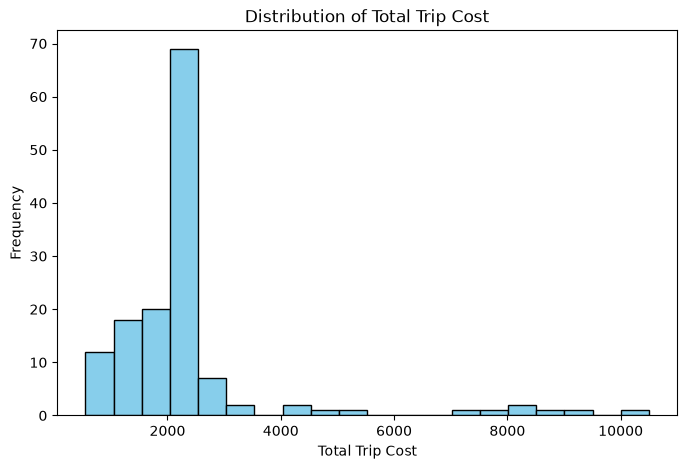

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Total Trip Cost"],
    bins=20,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Total Trip Cost")

plt.xlabel("Total Trip Cost")

plt.ylabel("Frequency")

plt.show()

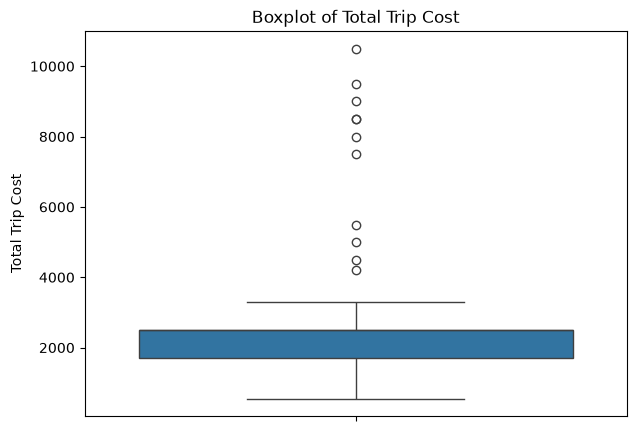

In [9]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    y=df["Total Trip Cost"]
)

plt.title("Boxplot of Total Trip Cost")

plt.ylabel("Total Trip Cost")

plt.show()

In [10]:
print("\nTop Travel Destinations")

destination_total = (
    df["Destination"]
    .value_counts()
)

print(destination_total.head(10))


Top Travel Destinations
Destination
Tokyo, Japan              7
Paris, France             7
Paris                     7
Bali                      7
Bali, Indonesia           5
Tokyo                     5
New York                  5
Sydney                    5
Rome                      5
Rio de Janeiro, Brazil    4
Name: count, dtype: int64



Accommodation Types
Accommodation type
Hotel              60
Airbnb             30
Hostel             24
Resort             14
Villa               4
Vacation rental     3
Unknown             2
Riad                1
Guesthouse          1
Name: count, dtype: int64


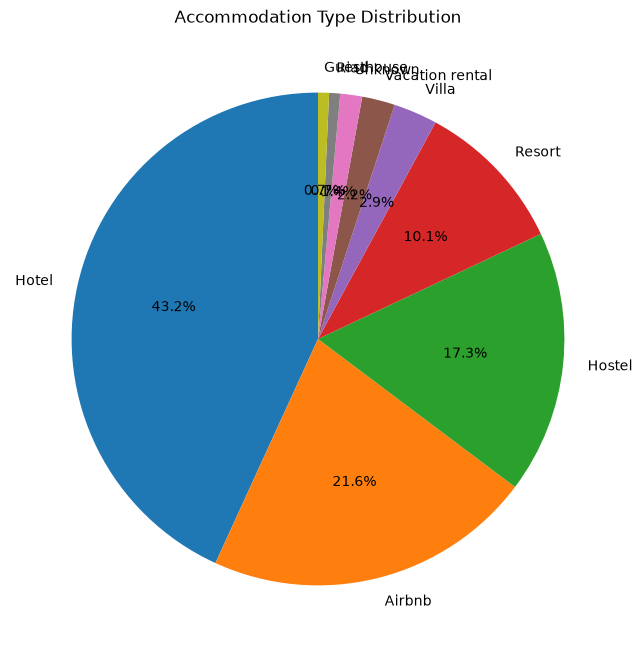

In [11]:
accommodation_total = (
    df["Accommodation type"]
    .value_counts()
)

print("\nAccommodation Types")

print(accommodation_total)

plt.figure(figsize=(8, 8))

accommodation_total.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Accommodation Type Distribution")

plt.show()


Traveler Gender Distribution
Traveler gender
Female     70
Male       67
Unknown     2
Name: count, dtype: int64


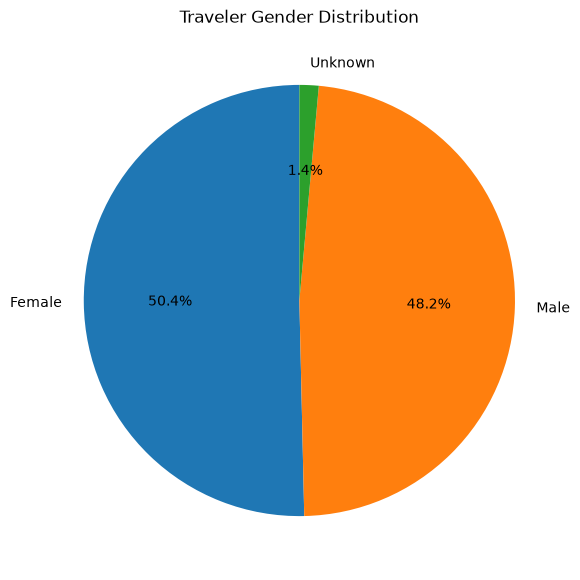

In [12]:
gender_total = (
    df["Traveler gender"]
    .value_counts()
)

print("\nTraveler Gender Distribution")

print(gender_total)

plt.figure(figsize=(7, 7))

gender_total.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Traveler Gender Distribution")

plt.show()

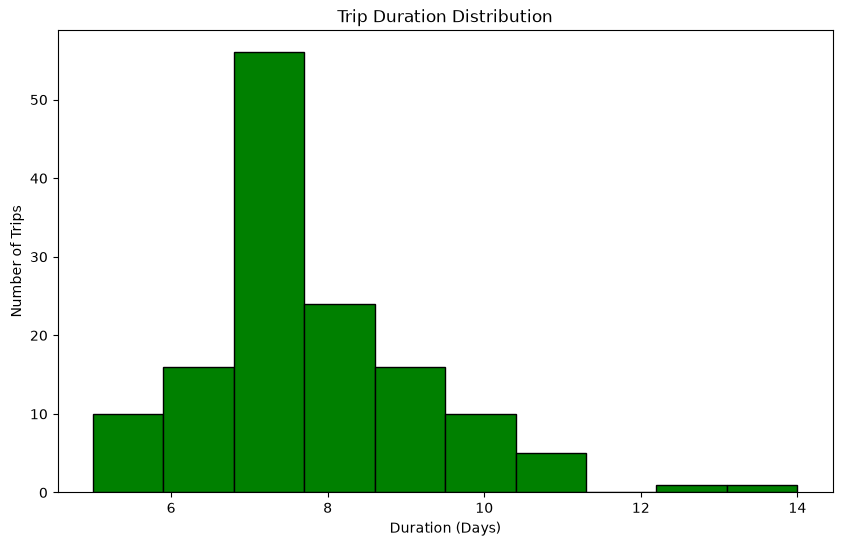

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Duration (days)"],
    bins=10,
    color="green",
    edgecolor="black"
)

plt.title("Trip Duration Distribution")

plt.xlabel("Duration (Days)")

plt.ylabel("Number of Trips")

plt.show()

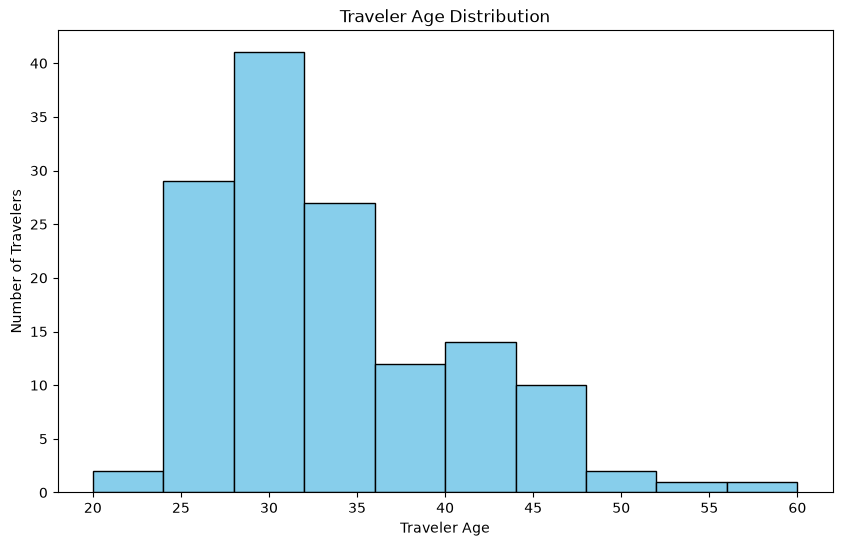

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Traveler age"],
    bins=10,
    color="skyblue",
    edgecolor="black"
)

plt.title("Traveler Age Distribution")

plt.xlabel("Traveler Age")

plt.ylabel("Number of Travelers")

plt.show()

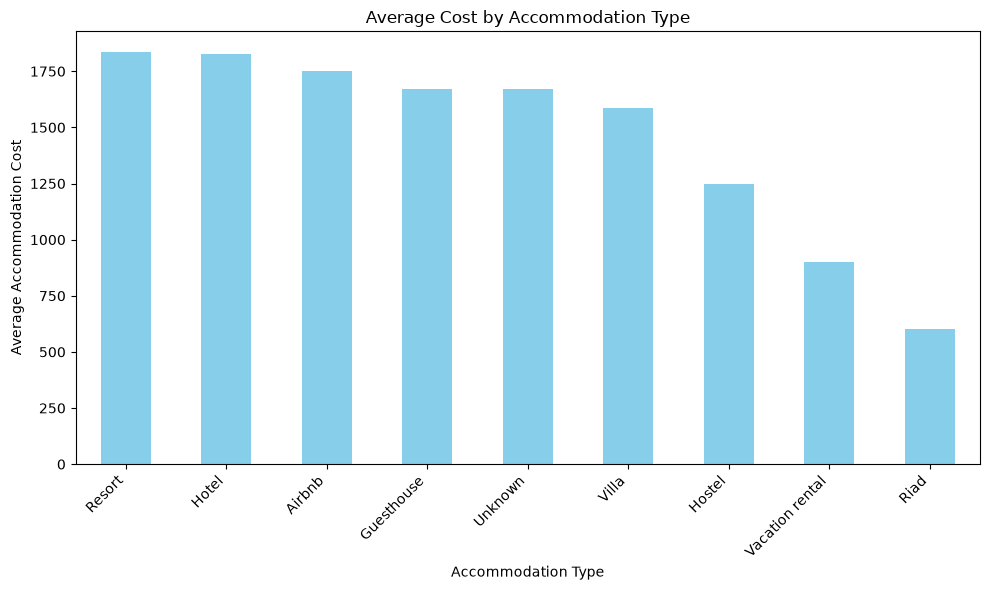

In [15]:
accommodation_cost = (
    df.groupby("Accommodation type")[
        "Accommodation cost"
    ]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

accommodation_cost.plot(
    kind="bar",
    color="skyblue"
)

plt.title("Average Cost by Accommodation Type")

plt.xlabel("Accommodation Type")

plt.ylabel("Average Accommodation Cost")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

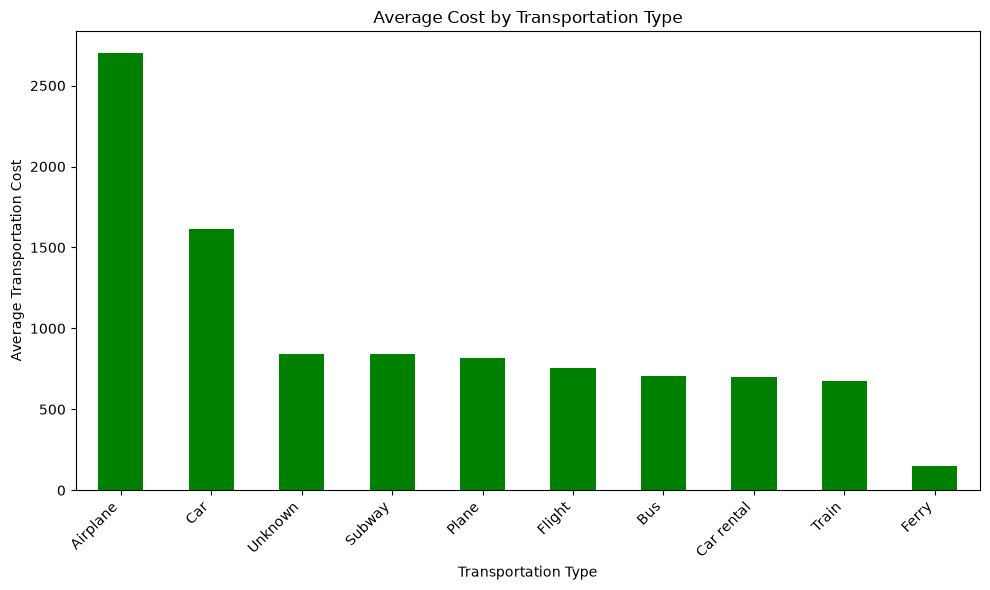

In [16]:
transportation_cost = (
    df.groupby("Transportation type")[
        "Transportation cost"
    ]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

transportation_cost.plot(
    kind="bar",
    color="green"
)

plt.title("Average Cost by Transportation Type")

plt.xlabel("Transportation Type")

plt.ylabel("Average Transportation Cost")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [17]:
print("\n========== PROJECT SUMMARY ==========")

print("1. Traveler Trip dataset loaded successfully.")

print("2. Dataset cleaned successfully.")

print("3. Missing values handled.")

print("4. Duplicate rows removed.")

print("5. Total trip cost calculated.")

print("6. Popular travel destinations identified.")

print("7. Traveler demographics analyzed.")

print("8. Accommodation preferences analyzed.")

print("9. Transportation preferences analyzed.")

print("10. Trip duration and cost relationships analyzed.")

print("11. Correlation analysis completed.")

print("12. Visualizations generated successfully.")

print("\nTraveler Trip Analysis EDA Completed Successfully!")


========== PROJECT SUMMARY ==========
1. Traveler Trip dataset loaded successfully.
2. Dataset cleaned successfully.
3. Missing values handled.
4. Duplicate rows removed.
5. Total trip cost calculated.
6. Popular travel destinations identified.
7. Traveler demographics analyzed.
8. Accommodation preferences analyzed.
9. Transportation preferences analyzed.
10. Trip duration and cost relationships analyzed.
11. Correlation analysis completed.
12. Visualizations generated successfully.

Traveler Trip Analysis EDA Completed Successfully!
